## Single Cell Example

This example downloads the `pancreas` differentiation dataset and fits an NB model like we've shared before. You can filter the number of genes using `pancreas = scdesigner.dataset.pancreas()[:, :n_genes]` but even with 1000 genes the computation is not too bad.

In [1]:
from scdesigner.simulators import NegBinCopula
import scdesigner.datasets

pancreas = scdesigner.datasets.pancreas()
pancreas

AnnData object with n_obs × n_vars = 2087 × 100
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'cell_type', 'sizeFactor', 'pseudotime'
    var: 'highly_variable_genes'
    uns: 'X_name', 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'PCA', 'UMAP', 'X_pca', 'X_umap'
    layers: 'counts', 'cpm', 'logcounts', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

This fits the model.

In [2]:
sim = NegBinCopula(mean_formula="bs(pseudotime, df=10)", dispersion_formula="bs(pseudotime, df=4)")
sim.fit(pancreas, max_epochs=50)

Epoch 50/50, Loss: 1.8503, Val Loss: 1.8612


Estimating copula correlation: 100%|██████████| 3/3 [00:01<00:00,  1.97it/s]


The sampled output is another anndata object.

In [3]:
samples = sim.sample()
samples

AnnData object with n_obs × n_vars = 2087 × 100
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'cell_type', 'sizeFactor', 'pseudotime'
    var: 'highly_variable_genes'

### Visual Checks [Optional]

We have a few helper functions to check the simulator, which we've placed in the `scdiagnostics` package. In the website, this will be replaced by more advanced interactive versions. `scdiagnostics` depends on the `altair` package, which might make installation difficult. The remaining dataset examples all work without the visualization steps, which is why we've indicated this section as "optional."

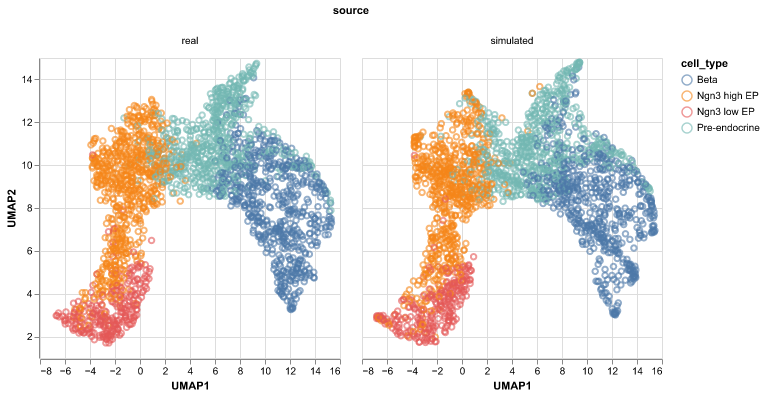

In [4]:
import scdiagnostics as scd
import altair
altair.renderers.enable('png')

scd.compare_umap(pancreas, samples, color="cell_type")

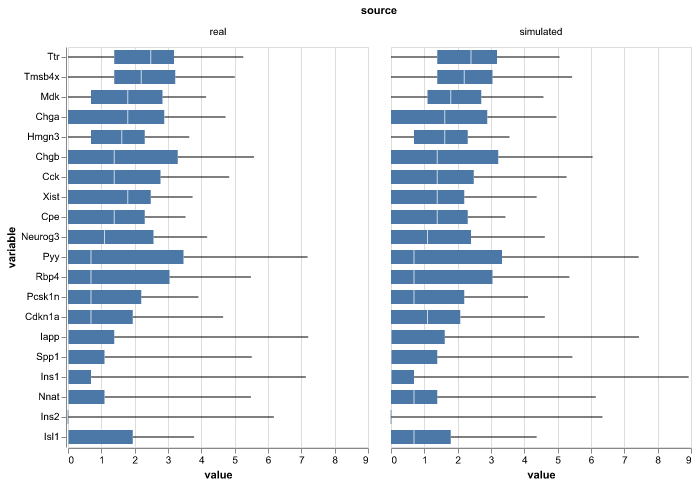

In [5]:
_  = scd.compare_boxplot(pancreas, samples, max_plot=20)

## Spatial Data Example

This is a spatial transcriptomics example using the acinar cell carcinoma dataset from the scDesign3 zenodo repository.

In [6]:
from scdesigner.simulators import SpatialNegBinCopula
import scdesigner.datasets

acinar = scdesigner.datasets.acinar()
acinar

AnnData object with n_obs × n_vars = 3043 × 1000
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'spatial1', 'spatial2', 'cell_type'
    uns: 'X_name'
    layers: 'logcounts'

This is our NB copula that automatically derives a spatial basis. We've set `basis="tps"` in this example because the default `"gp"` is too smooth for this dataset.

In [7]:
sim = SpatialNegBinCopula(mean_df=400, basis="tps", mean_extra_terms="cell_type")
sim.fit(acinar, max_epochs=50)

Epoch 50/50, Loss: 2.7852, Val Loss: 1.7802


Estimating copula correlation: 100%|██████████| 3/3 [00:09<00:00,  3.09s/it]


As before, the simulated output is an anndata object.

In [8]:
samples = sim.sample()
samples

AnnData object with n_obs × n_vars = 3043 × 1000
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'spatial1', 'spatial2', 'cell_type', 'sp_mean_0', 'sp_mean_1', 'sp_mean_2', 'sp_mean_3', 'sp_mean_4', 'sp_mean_5', 'sp_mean_6', 'sp_mean_7', 'sp_mean_8', 'sp_mean_9', 'sp_mean_10', 'sp_mean_11', 'sp_mean_12', 'sp_mean_13', 'sp_mean_14', 'sp_mean_15', 'sp_mean_16', 'sp_mean_17', 'sp_mean_18', 'sp_mean_19', 'sp_mean_20', 'sp_mean_21', 'sp_mean_22', 'sp_mean_23', 'sp_mean_24', 'sp_mean_25', 'sp_mean_26', 'sp_mean_27', 'sp_mean_28', 'sp_mean_29', 'sp_mean_30', 'sp_mean_31', 'sp_mean_32', 'sp_mean_33', 'sp_mean_34', 'sp_mean_35', 'sp_mean_36', 'sp_mean_37', 'sp_mean_38', 'sp_mean_39', 'sp_mean_40', 'sp_mean_41', 'sp_mean_42', 'sp_mean_43', 'sp_mean_44', 'sp_mean_45', 'sp_mean_46', 'sp_mean_47', 'sp_mean_48', 'sp_mean_49', 'sp_mean_50', 'sp_mean_51', 'sp_mean_52', 'sp_mean_53', 'sp_mean_54', 'sp_mean_55', 'sp_mean_56

### Visual Checks [Optional]

We'll make the same visualizations as above, but with an extra to compare the spatial expression patterns.

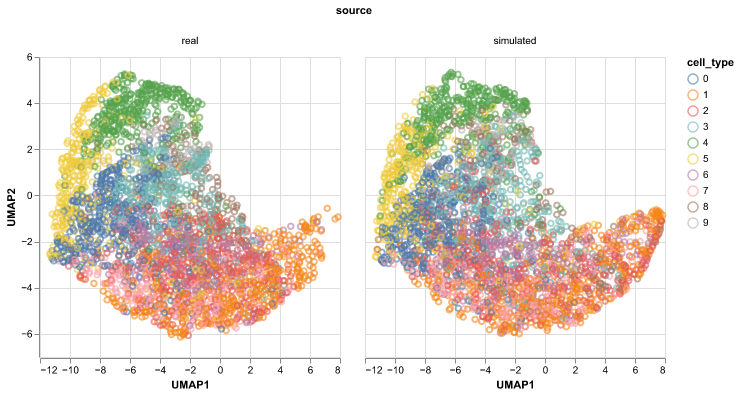

In [9]:
scd.compare_umap(acinar, samples, color="cell_type")

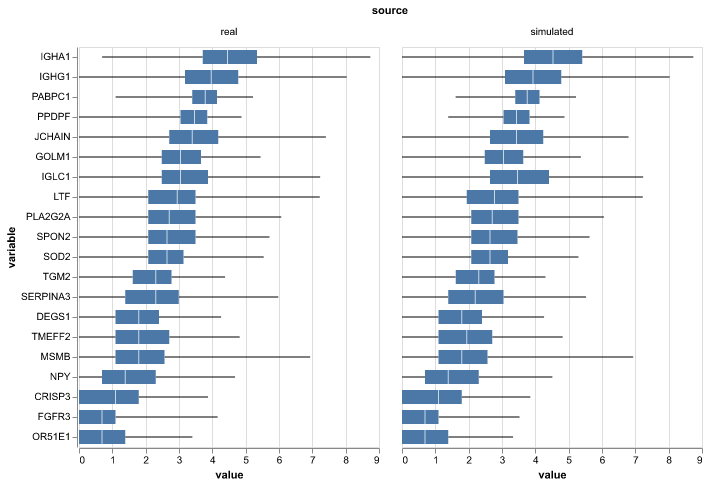

In [10]:
_ = scd.compare_boxplot(acinar, samples, max_plot=20)

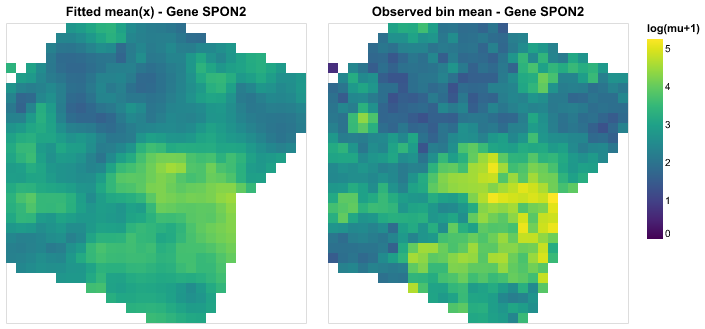

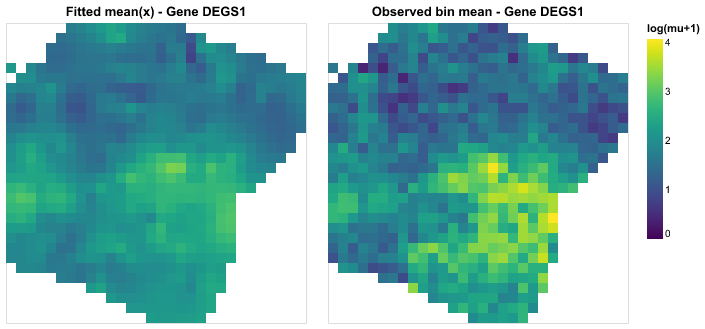

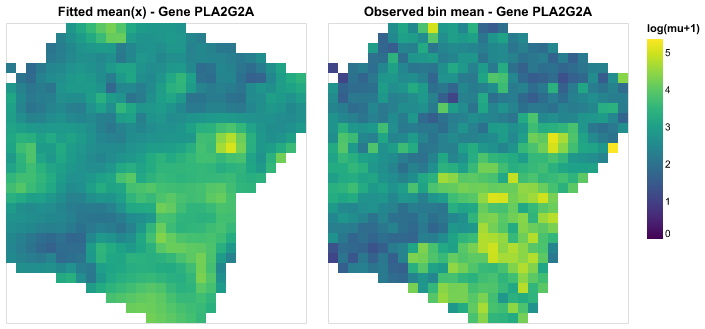

[None, None, None]

In [11]:
[display(scd.plot_mean_surface(sim, acinar, gene=g)) for g in acinar.var_names[:3]]

## scATAC-seq Example

This is the single-cell ATAC-seq dataset from the signac package, also from the scDesign3 zenodo reposiitory. Like in the scDesign3 paper, we use ZINB marginals. Note that the actual data have been preprocessed, though, and aren't exactly integer valued. The ZINB gives a reasonable approximation, but will always be constrained to integers.

In [12]:
from scdesigner.simulators import ZeroInflatedNegBinCopula

granja = scdesigner.datasets.granja_atac()
granja

AnnData object with n_obs × n_vars = 7034 × 1133
    obs: 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'passed_filters', 'cell_id', 'is__cell_barcode', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'peaks_snn_res.0.8', 'seurat_clusters', 'ident', 'cell_type'
    obsm: 'LSI', 'UMAP'

We have to specify formulas for each of the components of the ZINB model. The default learning rate is also a little too high for this example.

In [13]:
sim = ZeroInflatedNegBinCopula(mean_formula="~ cell_type", dispersion_formula="~ cell_type", zero_inflation_formula="~ cell_type")
sim.fit(granja, max_epochs=60, lr=0.1)

Epoch 60/60, Loss: 0.2718, Val Loss: 0.2770


Estimating copula correlation: 100%|██████████| 7/7 [00:01<00:00,  3.58it/s]


In [14]:
samples = sim.sample()
samples

AnnData object with n_obs × n_vars = 7034 × 1133
    obs: 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'passed_filters', 'cell_id', 'is__cell_barcode', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'peaks_snn_res.0.8', 'seurat_clusters', 'ident', 'cell_type'

### Visual Checks [Optional]

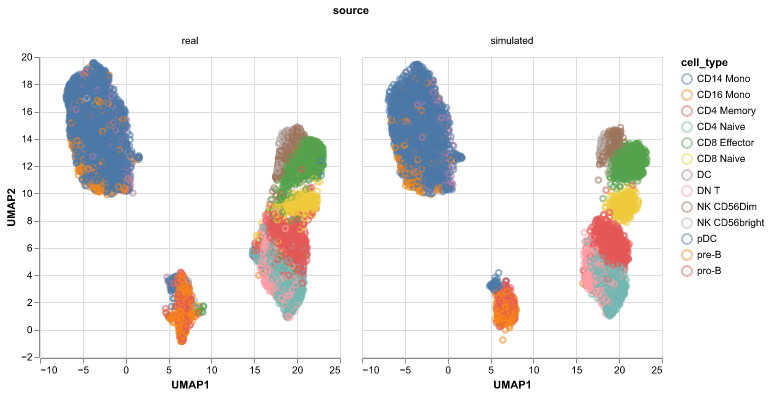

In [15]:
scd.compare_umap(granja, samples, color="cell_type")

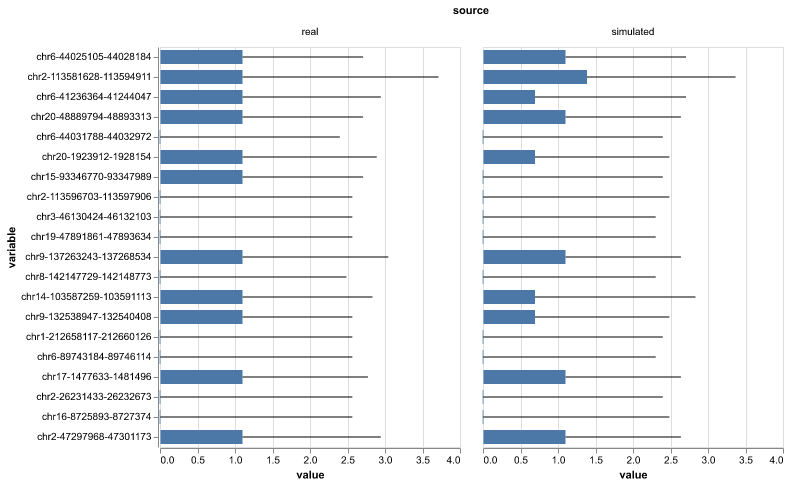

In [16]:
_ = scd.compare_boxplot(granja, samples, max_plot=20)